In [1]:
import ccdproc
from os import listdir
from astropy.io import fits
import glob
import pylab
from astropy.table import Table
import numpy as np 
import ccdproc as cp 
from glob import glob
import matplotlib.pyplot as plt
from ccdproc import *   
import astropy.units as u
import os
from glob import glob
import glob
import math 

In [2]:
# def subtract_fits_images(imageA_path, imageB_path, output_path='C.fit'):
#     """
#     将两个FITS图像相减：A - B = C
    
#     参数:
#     imageA_path: A.fits文件路径
#     imageB_path: B.fits文件路径  
#     output_path: 输出文件路径，默认为C.fits
#     """
    
#     # 检查文件是否存在
#     if not os.path.exists(imageA_path):
#         print(f"错误: 文件 {imageA_path} 不存在")
#         return
#     if not os.path.exists(imageB_path):
#         print(f"错误: 文件 {imageB_path} 不存在")
#         return
    
    # try:
    #     # 读取A图像
    #     with fits.open(imageA_path) as hdul_A:
    #         data_A = hdul_A[0].data.astype(np.float32)
    #         header_A = hdul_A[0].header.copy()
        
    #     # 读取B图像
    #     with fits.open(imageB_path) as hdul_B:
    #         data_B = hdul_B[0].data.astype(np.float32)
        
    #     # 检查图像尺寸是否匹配
    #     if data_A.shape != data_B.shape:
    #         print(f"错误: 图像尺寸不匹配")
    #         print(f"A图像尺寸: {data_A.shape}")
    #         print(f"B图像尺寸: {data_B.shape}")
    #         return
        
    #     # 执行减法：A - B
    #     result_data = data_A - data_B
        
    #     # 更新头信息
    #     #header_A['HISTORY'] = f'图像减法: {os.path.basename(imageA_path)} - {os.path.basename(imageB_path)}'
    #     #header_A['OPERATION'] = 'SUBTRACTION'
    #     #header_A['INPUT_A'] = (os.path.basename(imageA_path), '被减数图像')
    #     #header_A['INPUT_B'] = (os.path.basename(imageB_path), '减数图像')
        
    #     # 创建新的HDU并保存
    #     new_hdu = fits.PrimaryHDU(data=result_data, header=header_A)
    #     new_hdu.writeto(output_path, overwrite=True)
        
    #     # 打印成功信息
    #     print("图像减法完成!")
    #     print(f"输入文件A: {imageA_path}")
    #     print(f"输入文件B: {imageB_path}")
    #     print(f"输出文件: {output_path}")
    #     print(f"输入图像A尺寸: {data_A.shape}")
    #     print(f"输入图像B尺寸: {data_B.shape}")
    #     print(f"输出图像尺寸: {result_data.shape}")
    #     print(f"结果数据范围: {np.min(result_data):.2f} 到 {np.max(result_data):.2f}")
        
    # except Exception as e:
    #     print(f"处理过程中发生错误: {e}")


In [3]:
# subtract_fits_images('HIP19139-g80o50-0001-100ms.fit', 'dark-g80o50-0004-100ms.fit', 'HIP19139-g80o50-0001-100ms-subdark.fit')

In [4]:
# def takemean( path ):
#     fh=fits.open(path)     
#     return  fh[0].data[1050:1106,930:964].mean()

def takestat( path ):
    fh=fits.open(path)
     
        
    #return fh[0].header["EXPTIME"], fh[0].data[644:1140,860:1110].sum()   ### 取总和   
    return fh[0].header["EXPTIME"], fh[0].data[644:1140,960:1120].sum()   ### 取总和   要尽量大 覆盖到


    #return fh[0].header["EXPTIME"], fh[0].data[975:1114,918:995].mean()   ###取小范围    
    #return fh[0].header["EXPTIME"], fh[0].data[828:1212,886:1068].mean()    ####取适当范围（基本包括全部）


# def takevariance( path ):
#     fh=fits.open(path)
#     return  fh[0].data[1050:1106,930:964].var()/2

def takestd( path ):
    fh=fits.open(path)
    return  fh[0].data[650:1130,910:1150].std()
    
 

In [5]:
rows = []
for afile in glob.glob("66nm-0005-0d10s.fit"):
    rows.append(takestat(afile))
    print(rows)

[(0.1, 398313200)]


exptime
-------
   0.04
    0.1
    0.2
    0.5
   0.04
    0.1
    0.2
    0.5
   0.04
    0.1
    0.2
    0.5
      count       
------------------
        37695988.8
101286063.99999999
       193806617.6
       511425675.2
        37352468.8
101253103.99999999
       193634361.6
       507870507.2
        37435180.0
        97837968.0
       197922112.0
       513907648.0


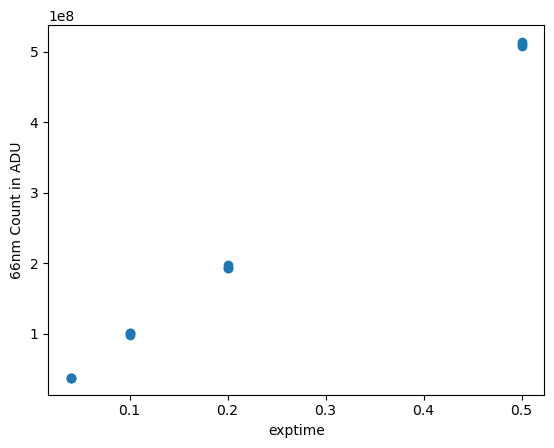

In [6]:

rows = []
for afile in glob.glob("66nm*subdark.fit"):
    rows.append(takestat(afile))
table = Table(rows=rows,names=("exptime","count")) 
pylab.xlabel("exptime")
pylab.ylabel("66nm Count in ADU")
pylab.plot(table["exptime"],table["count"],"o")

print(table["exptime"])
print(table["count"])
#5.236e+09 x - 3.279e+06


RMSE= 3676290.065637699
z1= [ 1.02931783e+09 -5.20443615e+06]
拟合后的公式是：
p1= 
1.029e+09 x - 5.204e+06± 3676290.065637699


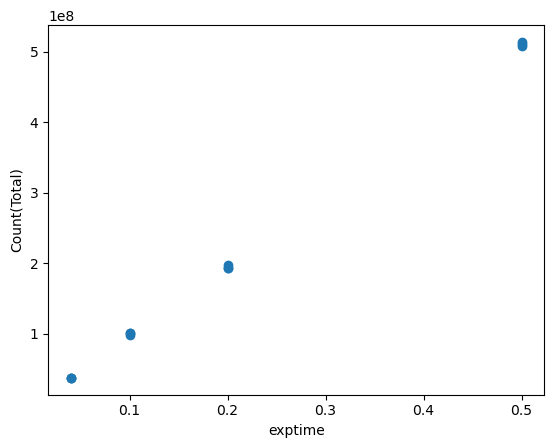

In [7]:
X = table["exptime"]
Y = table["count"]
pylab.xlabel("exptime")
pylab.ylabel("Count(Total)")
pylab.plot(X,Y,"o")

# z1 = np.polyfit(X, Y, 1)   ###线性拟合
# p1 = np.poly1d(z1)
# print('z1=',z1)
# print("拟合后的公式是：")
# print('p1=',p1)

z1 = np.polyfit(X, Y, 1)   ###线性拟合
slope, intercept = z1
y_fit = slope * X + intercept
residuals = Y - y_fit#残差
mse = np.mean(residuals**2)#均方误差
rmse = np.sqrt(mse)#均方根误差
p1 = np.poly1d(z1)
print('RMSE=',rmse)

print('z1=',z1)
print("拟合后的公式是：") 
#print('p1=',p1)#± 

#print("a ==  %s ,b == %s" % (a, b))
print("p1=%s± %s" % (p1,rmse))

In [12]:
from uncertainties import ufloat
x = ufloat(1.029e+09  - 5.204e+06,3676290.065637699)
print("一秒钟内的count数是",x)
gain =ufloat(0.0260,0.0012)
electron_num = gain * x
print("一秒钟内的电子数是")
print(f"{electron_num}")  

photo_num= ufloat(83795133.25,976075.9)

QE=electron_num / photo_num
print(QE)

一秒钟内的count数是 (1.024+/-0.004)e+09
一秒钟内的电子数是
(2.66+/-0.12)e+07
0.318+/-0.015
